# Stellar Luminosity

## Setup


In [1]:
# Install required libraries (run this once if needed)
%pip install numpy matplotlib

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.

In the following we find our dataset, where mass is the stellar mass in units of solar mass and the luminosity is the stellar luminosity in units of solar luminosity.We vectorize it using the library numpy to do numerical computation.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mass_array = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity_array = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

## Exploring the dataset

We can plot the mass-luminosity relationship to visualize the shape and range of the variables. We observe in the following function has a exponential shape, this leads us to think that using a linear model could be counterproductive, given that it might show systematic errors, especially,with masses greater than 1.50 because the relationship plots in a more exponential way.

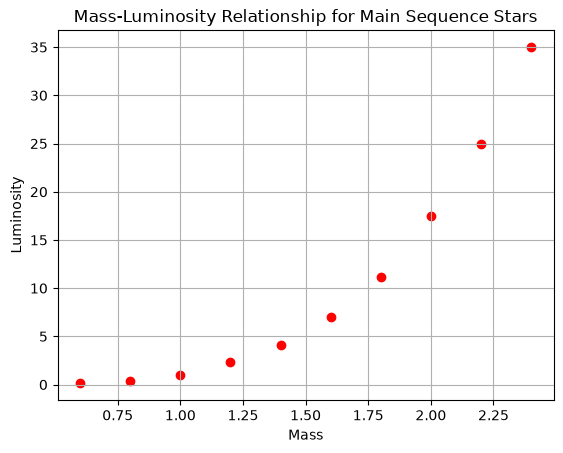

In [5]:
plt.scatter(mass_array,luminosity_array, color='r', label='Data Points')
plt.title('Mass-Luminosity Relationship for Main Sequence Stars')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid()

To reforce the hyphotesis of the shape of the relationship being plotted, we use a lynestyle to connect the dots:

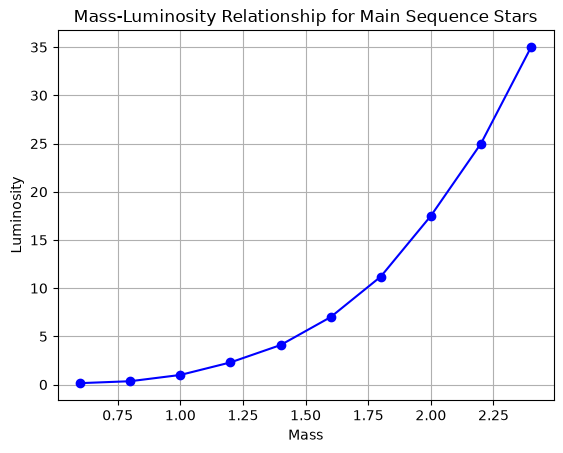

In [6]:
plt.plot(mass_array, luminosity_array, marker='o', linestyle='-', color='b')
plt.title('Mass-Luminosity Relationship for Main Sequence Stars')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid()

## Training Learn Functions

In [7]:
def build_polynomial_features(x, degree=2):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    features = []
    for d in range(1, degree + 1):
        features.append(x ** d)
    return np.column_stack(features)

def predict(X, w, b):
    return X @ w + b

def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    errors = y_hat - y
    return np.sum(errors**2) / (2 * m)

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    errors = y_hat - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_progress=True):
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        history_it.append(i)
        history_cost.append(cost)

    return w, b, history_it, history_cost

def feature_scale(X):
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds

## Linear Model Training

Below we follow the training procedure step by step:
1. Initialize the parameters.
2. Select a learning rate and the number of iterations.
3. Train the model with gradient descent.
4. Plot the cost over time.
5. Plot the fitted line against the observations.
6. Report the final parameters and cost.
7. Diagnose convergence and possible systematic errors.


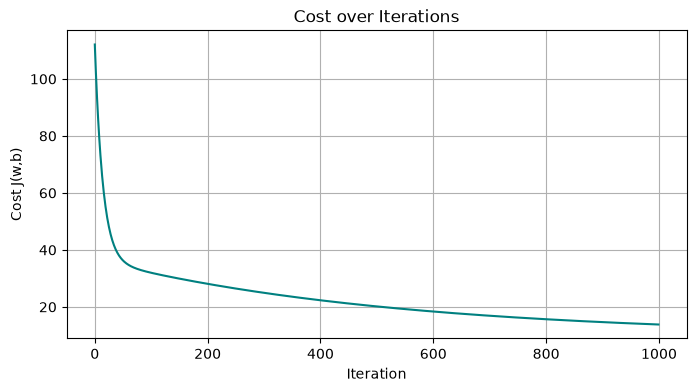

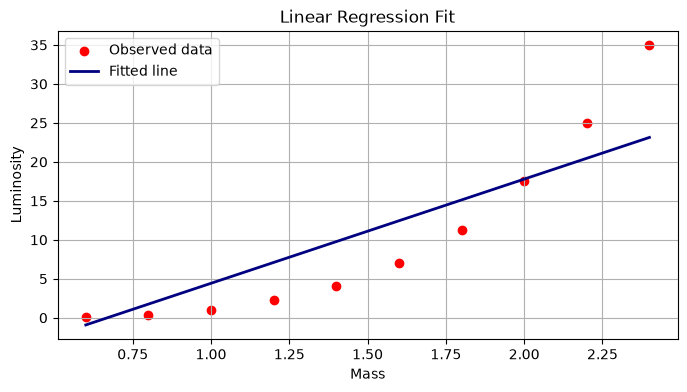

Final parameters: w = [13.3647611], b = -8.939533
Final cost: 13.821822
Residuals:
[ -1.07067605   1.40227617   3.42522839   4.79818061   5.67113283
   5.44408505   3.91703727   0.28998949  -4.53705829 -11.86410607]


In [8]:
x_linear = np.array(mass_array).reshape(-1, 1)

w_init = np.zeros(1)
b_init = 0.0

alpha = 0.01
num_iterations = 1000

# Training
w_final, b_final, history_it, history_cost = gradient_descent(
    x_linear,
    luminosity_array,
    w_init,
    b_init,
    alpha,
    num_iterations,
    print_progress=False
)

# Plotting
iterations = history_it
costs = history_cost

plt.figure(figsize=(8, 4))
plt.plot(iterations, costs, color='teal')
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.grid(True)
plt.show()

# Fitted line with the observations
x_fit = np.linspace(min(x_linear), max(x_linear), 200).reshape(-1, 1)
y_fit = predict(x_fit, w_final, b_final)

plt.figure(figsize=(8, 4))
plt.scatter(x_linear, luminosity_array, color='red', label='Observed data')
plt.plot(x_fit, y_fit, color='navy', linewidth=2, label='Fitted line')
plt.title('Linear Regression Fit')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid(True)
plt.legend()
plt.show()


final_cost = compute_cost(x_linear, luminosity_array, w_final, b_final)
print(f"Final parameters: w = {np.array2string(w_final)}, b = {b_final:.6f}")
print(f"Final cost: {final_cost:.6f}")

# Convergence and systematic errors
predictions = predict(x_linear, w_final, b_final)
residuals_linear = predictions - luminosity_array

print("Residuals:")
print(residuals_linear)

As we can see, the fitted line has too many systemic errors when compared to the observed data, showing that a lineal model was not adequate.

## Polynominial Model Training

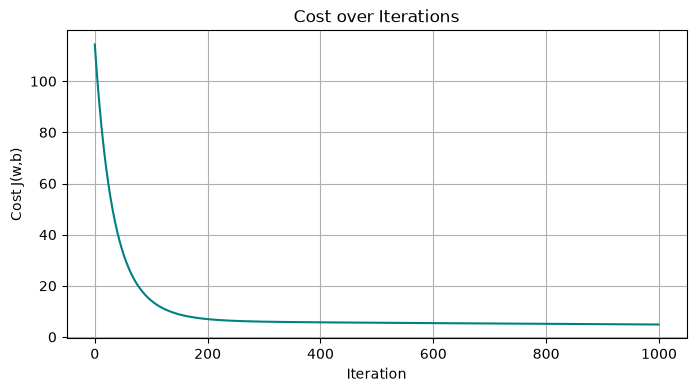

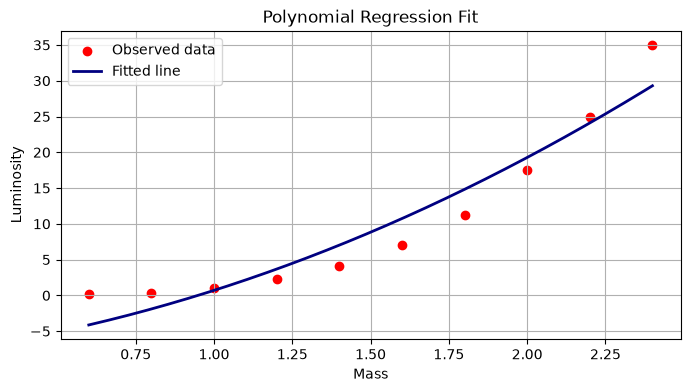

Residuals:
[-4.27968453 -2.24772287 -0.29531039  1.37755291  2.92086702  3.73463194
  3.61884769  1.77351425 -0.90136838 -5.70580019]


In [9]:
degree = 2
x_polynomial = build_polynomial_features(mass_array, degree=degree)
x_polynomial_scaled, means_poly, stds_poly = feature_scale(x_polynomial)

w_init = np.zeros(x_polynomial_scaled.shape[1])
b_init = 0.0

w_poly, b_poly, history_it_poly, history_cost_poly = gradient_descent(
    x_polynomial_scaled,
    luminosity_array,
    w_init,
    b_init,
    alpha,
    num_iterations,
    print_progress=False
)

iterations = history_it_poly
costs = history_cost_poly

plt.figure(figsize=(8, 4))
plt.plot(iterations, costs, color='teal')
plt.title('Cost over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.grid(True)
plt.show()

# Fitting the polynomial regression model to the data
x_fit = np.linspace(np.min(mass_array), np.max(mass_array), 200)
x_fit_poly = build_polynomial_features(x_fit, degree=degree)

x_fit_poly_scaled = (x_fit_poly - means_poly) / stds_poly

y_fit = predict(x_fit_poly_scaled, w_poly, b_poly)

plt.figure(figsize=(8, 4))
plt.scatter(mass_array, luminosity_array, color='red', label='Observed data')
plt.plot(x_fit, y_fit, color='navy', linewidth=2, label='Fitted line')
plt.title('Polynomial Regression Fit')
plt.xlabel('Mass')
plt.ylabel('Luminosity')
plt.grid(True)
plt.legend()
plt.show()

predictions_poly = predict(x_polynomial_scaled, w_poly, b_poly)
residuals_poly = predictions_poly - luminosity_array

print("Residuals:")
print(residuals_poly)

## Comparation of both models


In [20]:

linear_cost = compute_cost(x_linear, luminosity_array, w_final, b_final)
poly_cost = compute_cost(x_polynomial_scaled, luminosity_array, w_poly, b_poly)

print("Final costs:")
print(f"Linear model: {linear_cost:.6f}")
print(f"Polynomial model: {poly_cost:.6f}")
print(f"Cost difference (linear - polynomial): {linear_cost - poly_cost:.6f}")

Final costs:
Linear model: 13.821822
Polynomial model: 4.872089
Cost difference (linear - polynomial): 8.949733


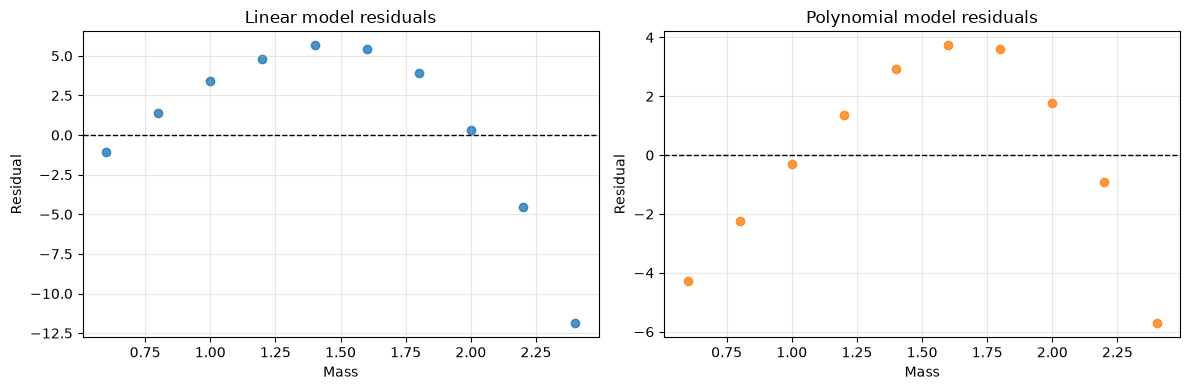

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(mass_array, residuals_linear, color='tab:blue', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Linear model residuals')
axes[0].set_xlabel('Mass')
axes[0].set_ylabel('Residual')
axes[0].grid(alpha=0.3)

axes[1].scatter(mass_array, residuals_poly, color='tab:orange', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Polynomial model residuals')
axes[1].set_xlabel('Mass')
axes[1].set_ylabel('Residual')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

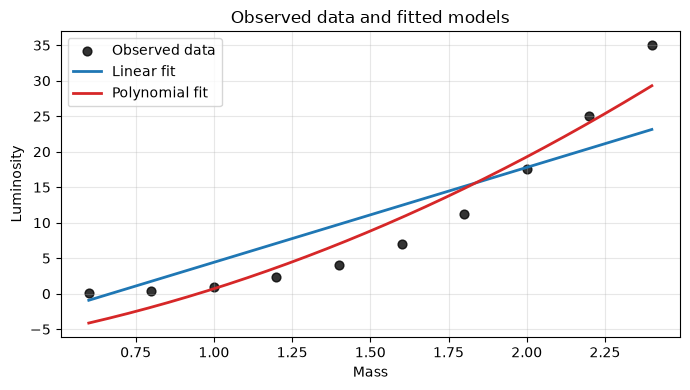

In [18]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(mass_array, luminosity_array, color='black', s=40, alpha=0.8, label='Observed data')

x_lin_fit = np.linspace(mass_array.min(), mass_array.max(), 200).reshape(-1, 1)
y_lin_fit = predict(x_lin_fit, w_final, b_final)
ax.plot(x_lin_fit[:, 0], y_lin_fit, color='tab:blue', linewidth=2, label='Linear fit')

x_poly_fit = np.linspace(mass_array.min(), mass_array.max(), 200)
x_poly_fit_features = build_polynomial_features(x_poly_fit, degree=degree)
x_poly_fit_scaled = (x_poly_fit_features - means_poly) / stds_poly
y_poly_fit = predict(x_poly_fit_scaled, w_poly, b_poly)
ax.plot(x_poly_fit, y_poly_fit, color='tab:red', linewidth=2, label='Polynomial fit')

ax.set_title('Observed data and fitted models')
ax.set_xlabel('Mass')
ax.set_ylabel('Luminosity')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Testing of the predictions

We do the following tests of the predictions . At first, we use a mass of 1.3, a range inside the observer range, and we do too a mass of 5.0, that is far outisde the observed range.

In [11]:
test_mass = np.array([1.3, 5.0])

for mass in test_mass:
    x_lin = np.array([[mass]], dtype=float)
    pred_linear = float(predict(x_lin, w_final, b_final)[0])

    x_poly = build_polynomial_features(np.array([mass], dtype=float), degree=degree)
    x_poly_scaled = (x_poly - means_poly) / stds_poly
    pred_poly = float(predict(x_poly_scaled, w_poly, b_poly)[0])

    print(f"mass: {mass:.1f}")
    print(f"linear model: {pred_linear:.3f}")
    print(f"polynomial model: {pred_poly:.3f}")
    print()

mass: 1.3
linear model: 8.435
polynomial model: 5.303

mass: 5.0
linear model: 57.884
polynomial model: 130.548



Based on the results, we can conclude that for the mass of 1.3 both predictions are relativity adequate as interpolations and don't have a great difference but for 5.0 we can't trust the predictions because they are outside the data used to fit the models and show a huge difference.

## Reflections


What does this regression experiment reveal—and what does it fail to reveal—about how more advanced AI systems learn?

Do you think Artificial General Intelligence is achievable? Explain what you understand by AGI and why you believe it is—or is not—reachable.

Could AGI emerge primarily by scaling neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?

One question about AI-driven systems that I want to explore during the semester is: ______________________________